# RSNA Pneumonia Detection Coding Assignment
**Student Name:** ISHAAN KUMAR  
**Registration ID:** S24BCAU0183  
**Batch:** B6

In [1]:
import pandas as pd
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
import os
import torchvision.transforms.functional as TF
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision

# High Stability Settings for GPU
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.cuda.empty_cache()

In [2]:
LABELS_PATH = "stage_2_train_labels.csv"
IMAGE_DIR = "stage_2_train_images"
labels = pd.read_csv(LABELS_PATH)
print("Total rows:", len(labels))
labels.head()

Total rows: 30227


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [3]:
print(labels["Target"].value_counts())
all_ids = labels["patientId"].unique()
print("Total patients:", len(all_ids))

Target
0    20672
1     9555
Name: count, dtype: int64
Total patients: 26684


In [4]:
def get_boxes(patient_id):
    records = labels[labels['patientId'] == patient_id]
    boxes = []
    for _, row in records.iterrows():
        if row['Target'] == 1:
            x1 = row['x']
            y1 = row['y']
            x2 = x1 + row['width']
            y2 = y1 + row['height']
            boxes.append([x1, y1, x2, y2])
    return boxes

def load_image(path):
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array
    orig_h, orig_w = img.shape
    img = cv2.resize(img, (256, 256))
    img = img / 255.0
    return img, (orig_w, orig_h)

def show_image_with_boxes(patient_id):
    path = os.path.join(IMAGE_DIR, f"{patient_id}.dcm")
    img, (orig_w, orig_h) = load_image(path)
    boxes = get_boxes(patient_id)
    scale_x = 256 / orig_w
    scale_y = 256 / orig_h
    img_copy = img.copy()
    for box in boxes:
        x1, y1, x2, y2 = box
        x1 = int(x1 * scale_x)
        x2 = int(x2 * scale_x)
        y1 = int(y1 * scale_y)
        y2 = int(y2 * scale_y)
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (1, 0, 0), 2)
    plt.imshow(img_copy, cmap='gray')
    plt.title(f"Patient ID: {patient_id}")
    plt.axis("off")
    plt.show()

In [5]:
class RSNADataset(Dataset):
    def __init__(self, image_dir, labels_df, image_ids, augment=False):
        self.image_dir = image_dir
        self.labels_df = labels_df
        self.image_ids = image_ids
        self.augment   = augment
    def __len__(self):
        return len(self.image_ids)
    def __getitem__(self, idx):
        patient_id = self.image_ids[idx]
        path = os.path.join(self.image_dir, f"{patient_id}.dcm")
        dicom = pydicom.dcmread(path)
        img = dicom.pixel_array.astype(np.float32)
        orig_h, orig_w = img.shape
        img = cv2.resize(img, (256, 256))
        img = img / 255.0
        img_t = torch.tensor(img).unsqueeze(0).repeat(3, 1, 1)
        records = self.labels_df[self.labels_df["patientId"] == patient_id]
        boxes = []
        for _, row in records.iterrows():
            if row["Target"] == 1:
                x1 = row["x"] * (256 / orig_w)
                y1 = row["y"] * (256 / orig_h)
                x2 = (row["x"] + row["width"])  * (256 / orig_w)
                y2 = (row["y"] + row["height"]) * (256 / orig_h)
                # Clamp boxes to image size
                x1 = max(0, min(256, x1))
                y1 = max(0, min(256, y1))
                x2 = max(x1 + 1, min(256, x2))
                y2 = max(y1 + 1, min(256, y2))
                boxes.append([x1, y1, x2, y2])
        if len(boxes) == 0:
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_t  = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.ones((len(boxes),), dtype=torch.int64)
        if self.augment and len(boxes_t) > 0:
            if random.random() > 0.5:
                img_t = TF.hflip(img_t)
                boxes_t[:, [0, 2]] = 256 - boxes_t[:, [2, 0]]
        target = {"boxes": boxes_t, "labels": labels_t}
        return img_t, target

In [6]:
pos_ids = labels[labels["Target"] == 1]["patientId"].unique()
neg_ids = labels[labels["Target"] == 0]["patientId"].unique()
pos_sample = np.random.choice(pos_ids, 50, replace=False)
neg_sample = np.random.choice(neg_ids, 50, replace=False)
selected_ids = list(pos_sample) + list(neg_sample)
from sklearn.model_selection import train_test_split
train_ids, val_ids = train_test_split(selected_ids, test_size=0.2)
print(f"Train: {len(train_ids)}, Val: {len(val_ids)}")

Train: 80, Val: 20


In [7]:
train_dataset = RSNADataset(IMAGE_DIR, labels, train_ids, augment=True)
val_dataset   = RSNADataset(IMAGE_DIR, labels, val_ids,   augment=False)
def collate_fn(batch):
    return tuple(zip(*batch))
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

In [8]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
print("Using:", device)

Using: cuda


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [10]:
num_epochs = 5 # Run for 5 epochs as requested
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {total_train_loss:.4f}")

Epoch 1/5  Train Loss: 7.1148


Epoch 2/5  Train Loss: 6.4910


Epoch 3/5  Train Loss: 6.6906


Epoch 4/5  Train Loss: 6.6932


Epoch 5/5  Train Loss: 6.5968


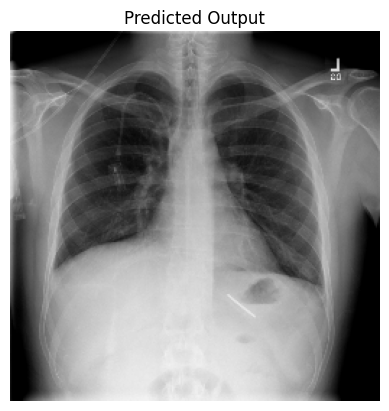

In [11]:
def show_predictions(model, dataset, device, idx=0, threshold=0.5):
    model.eval()
    img, target = dataset[idx]
    with torch.no_grad():
        prediction = model([img.to(device)])
    pred_boxes = prediction[0]["boxes"].cpu().numpy()
    scores     = prediction[0]["scores"].cpu().numpy()
    img_np = img[0].cpu().numpy()
    img_np = (img_np * 255).astype(np.uint8)
    img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    for box, score in zip(pred_boxes, scores):
        if score >= threshold:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_np, (x1, y1), (x2, y2), (255, 0, 255), 2)
    plt.imshow(img_np)
    plt.title("Predicted Output")
    plt.axis("off")
    plt.show()
show_predictions(model, val_dataset, device, idx=0)